# Data Preprocessing and Feature Engineering


## 1. Data Analysis


### Tensor


In [1]:
import os
import json
import sqlite3
import warnings
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import (LabelEncoder, OrdinalEncoder, OneHotEncoder,
                                   StandardScaler, MinMaxScaler, MaxAbsScaler,
                                   RobustScaler, Normalizer, KBinsDiscretizer,
                                   FunctionTransformer, PowerTransformer,
                                   Binarizer)
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")
print("Libraries loaded")


Libraries loaded


## 2. Data Import


In [2]:
import os

if os.path.exists("../Dataset/customers.xlsx"):
    DATA_DIR = "../Dataset"
else:
    DATA_DIR = "Dataset"

FINAL_DIR = os.path.join(os.path.dirname(DATA_DIR), "Final Dataset")
SCREEN_DIR = os.path.join(os.path.dirname(DATA_DIR), "Screenshots")
os.makedirs(FINAL_DIR, exist_ok=True)
os.makedirs(SCREEN_DIR, exist_ok=True)

customers = pd.read_excel(os.path.join(DATA_DIR, "customers.xlsx"))
with open(os.path.join(DATA_DIR, "transactions.json"), "r", encoding="utf-8") as f:
    transactions = pd.DataFrame(json.load(f))

conn = sqlite3.connect(":memory:")
with open(os.path.join(DATA_DIR, "products.sql"), "r", encoding="utf-8") as f:
    conn.executescript(f.read())
products = pd.read_sql_query("SELECT * FROM products", conn)
conn.close()

print("Customers:", customers.shape)
print("Transactions:", transactions.shape)
print("Products:", products.shape)


Customers: (8, 6)
Transactions: (8, 6)
Products: (6, 5)


In [3]:
api_url = "https://dummyjson.com/users"
try:
    response = requests.get(api_url, timeout=10)
    response.raise_for_status()
    api_users = pd.DataFrame(response.json().get("users", []))
    print("API status:", response.status_code, "| Rows:", len(api_users))
    display(api_users.head())
except Exception as e:
    api_users = pd.DataFrame()
    print("API unavailable:", type(e).__name__)

API status: 200 | Rows: 30


,id,firstName,lastName,maidenName,age,gender,email,phone,username,password,...,address,macAddress,university,bank,company,ein,ssn,userAgent,crypto,role
0,1,Emily,Johnson,Smith,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,emilyspass,...,"{'address': '626 Main Street', 'city': 'Phoeni...",47:fa:41:18:ec:eb,University of Wisconsin--Madison,"{'cardExpire': '05/28', 'cardNumber': '3693233...","{'department': 'Engineering', 'name': 'Dooley,...",977-175,900-590-289,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
1,2,Michael,Williams,,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,michaelwpass,...,"{'address': '385 Fifth Street', 'city': 'Houst...",79:15:78:99:60:aa,Ohio State University,"{'cardExpire': '01/30', 'cardNumber': '3530633...","{'department': 'Support', 'name': 'Spinka - Di...",912-602,108-953-962,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
2,3,Sophia,Brown,,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,sophiabpass,...,"{'address': '1642 Ninth Street', 'city': 'Wash...",12:a3:d3:6f:5c:5b,Pepperdine University,"{'cardExpire': '10/27', 'cardNumber': '6011212...","{'department': 'Research and Development', 'na...",963-113,638-461-822,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
3,4,James,Davis,,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,jamesdpass,...,"{'address': '238 Jefferson Street', 'city': 'S...",10:7d:df:1f:97:58,University of Southern California,"{'cardExpire': '07/30', 'cardNumber': '5303440...","{'department': 'Support', 'name': 'Pagac and S...",904-810,116-951-314,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
4,5,Emma,Miller,Johnson,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,emmajpass,...,"{'address': '607 Fourth Street', 'city': 'Jack...",32:b9:7e:8d:f5:e8,Northeastern University,"{'cardExpire': '07/30', 'cardNumber': '5237188...","{'department': 'Human Resources', 'name': 'Gra...",403-505,526-210-885,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin


## 3. Data Understanding and Cleaning


In [4]:
print("Customers info")
customers.info()
print("\nTransactions info")
transactions.info()
print("\nProducts info")
products.info()

print("\nDuplicate rows")
print({
    "customers": customers.duplicated().sum(),
    "transactions": transactions.duplicated().sum(),
    "products": products.duplicated().sum()
})

print("\nCustomer statistics")
display(customers.describe(include="all"))

Customers info
<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  8 non-null      int64
 1   name         8 non-null      str  
 2   age          8 non-null      int64
 3   gender       8 non-null      str  
 4   city         8 non-null      str  
 5   income       8 non-null      int64
dtypes: int64(3), str(3)
memory usage: 516.0 bytes

Transactions info
<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   transaction_id  8 non-null      str  
 1   customer_id     8 non-null      int64
 2   product_id      8 non-null      str  
 3   amount          8 non-null      int64
 4   payment_mode    8 non-null      str  
 5   date            8 non-null      str  
dtypes: int64(2), str(4)
memory usage: 516.0 bytes

Products info
<class 

,customer_id,name,age,gender,city,income
count,8.00000,8,8.000000,8,8,8.000000
unique,NaN,8,NaN,2,8,NaN
top,NaN,Aarav,NaN,Male,Mumbai,NaN
freq,NaN,1,NaN,4,1,NaN
mean,104.50000,NaN,30.000000,NaN,NaN,54125.000000
std,2.44949,NaN,5.903994,NaN,NaN,10494.045931
min,101.00000,NaN,22.000000,NaN,NaN,42000.000000
25%,102.75000,NaN,26.250000,NaN,NaN,47250.000000
50%,104.50000,NaN,29.500000,NaN,NaN,52500.000000
75%,106.25000,NaN,33.500000,NaN,NaN,58500.000000


In [5]:
customer_transactions = customers.merge(transactions, on="customer_id", how="left")
combined_data = customer_transactions.merge(products, on="product_id", how="left")
combined_data["date"] = pd.to_datetime(combined_data["date"], errors="coerce")

print("Combined shape:", combined_data.shape)
display(combined_data.head())

Combined shape: (8, 15)


,customer_id,name,age,gender,city,income,transaction_id,product_id,amount,payment_mode,date,product_name,category,price,stock
0,101,Aarav,24,Male,Mumbai,45000,T001,P001,499,UPI,2025-10-01,Earphones,Electronics,499,50
1,102,Diya,30,Female,Delhi,55000,T007,P003,1499,Credit Card,2025-10-09,Smart Watch,Wearable,1299,25
2,103,Kabir,27,Male,Bangalore,48000,T002,P003,1299,Credit Card,2025-10-02,Smart Watch,Wearable,1299,25
3,104,Meera,35,Female,Ahmedabad,60000,T003,P002,699,Debit Card,2025-10-03,Bluetooth Speaker,Audio,699,40
4,105,Vivaan,40,Male,Pune,75000,T004,P005,1999,UPI,2025-10-05,Headphones,Audio,1999,30


## 4. Exploratory Data Analysis


Numerical: ['customer_id', 'age', 'income', 'amount', 'price', 'stock']
Categorical: ['name', 'gender', 'city', 'transaction_id', 'product_id', 'payment_mode', 'product_name', 'category']


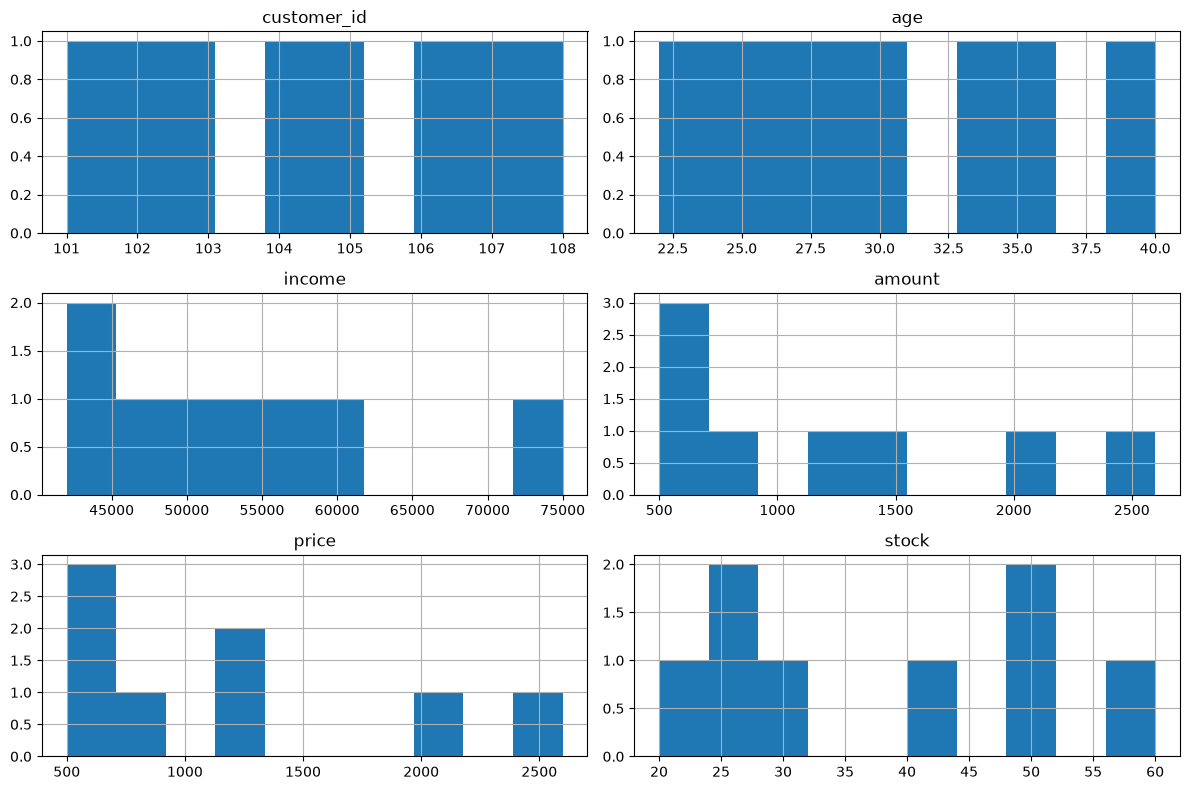

In [6]:
num_cols = combined_data.select_dtypes(include=np.number).columns.tolist()
cat_cols = combined_data.select_dtypes(include="object").columns.tolist()
print("Numerical:", num_cols)
print("Categorical:", cat_cols)

combined_data[num_cols].hist(figsize=(12, 8), bins=10)
plt.tight_layout()
plt.show()

Univariate: payment mode


payment_mode
UPI            3
Credit Card    2
Cash           2
Debit Card     1
Name: count, dtype: int64

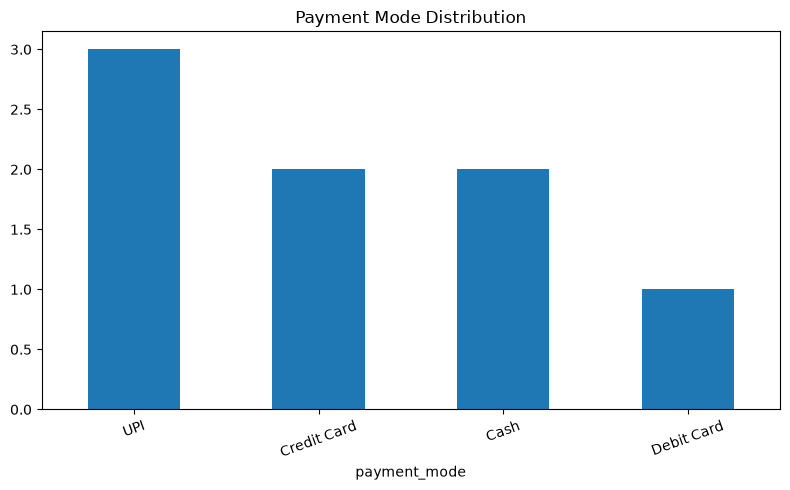

In [7]:
print("Univariate: payment mode")
display(combined_data["payment_mode"].value_counts())

plt.figure(figsize=(8,5))
combined_data["payment_mode"].value_counts().plot(kind="bar")
plt.title("Payment Mode Distribution")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

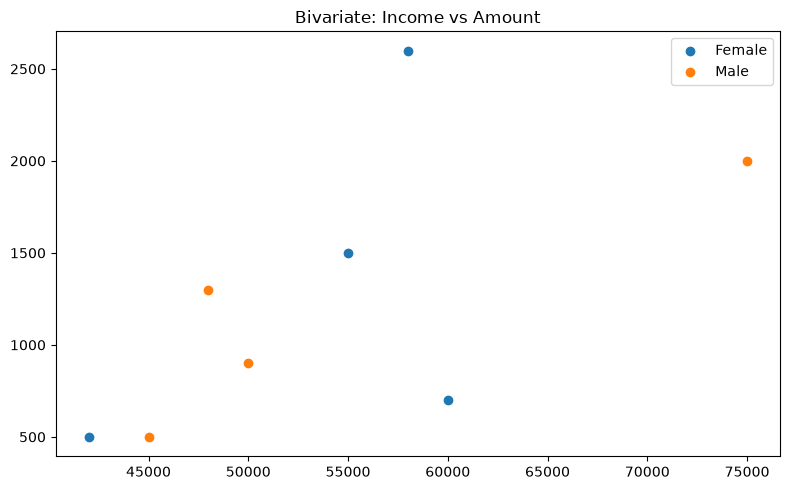

In [8]:
plt.figure(figsize=(8,5))
for label, group in combined_data.groupby("gender"):
    plt.scatter(group["income"], group["amount"], label=label)
plt.legend()
plt.title("Bivariate: Income vs Amount")
plt.tight_layout()
plt.show()

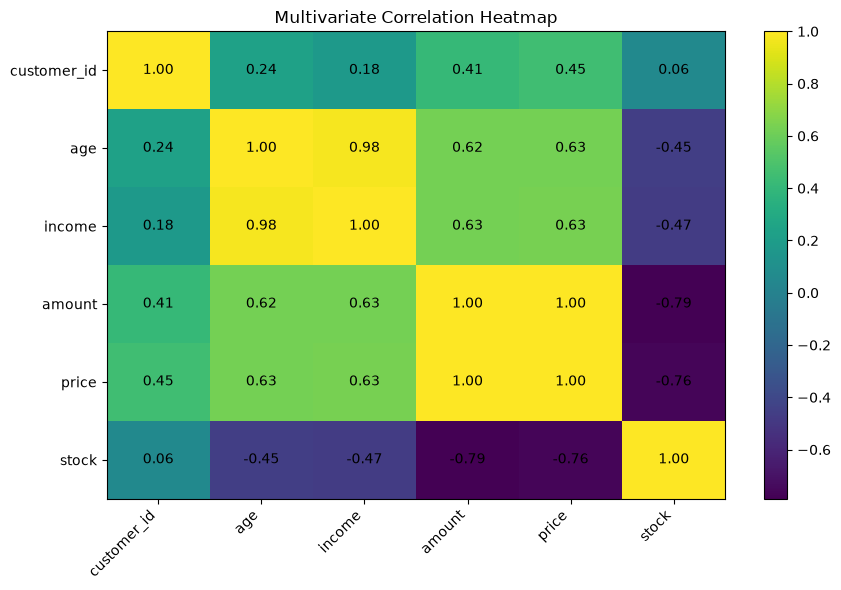

In [9]:
plt.figure(figsize=(9,6))
plt.imshow(combined_data[num_cols].corr(), aspect="auto")
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        plt.text(j, i, f"{combined_data[num_cols].corr().iloc[i,j]:.2f}", ha="center", va="center")
plt.title("Multivariate Correlation Heatmap")
plt.tight_layout()
plt.show()

### Pandas Profiling


In [10]:
# Pandas profiling
profile_summary = pd.DataFrame({
    "dtype": combined_data.dtypes.astype(str),
    "missing": combined_data.isnull().sum(),
    "unique": combined_data.nunique()
})
print("Shape:", combined_data.shape)
display(profile_summary)
display(combined_data.describe(include="all").T)


Shape: (8, 15)


,dtype,missing,unique
customer_id,int64,0,8
name,str,0,8
age,int64,0,8
gender,str,0,2
city,str,0,8
income,int64,0,8
transaction_id,str,0,8
product_id,str,0,6
amount,int64,0,7
payment_mode,str,0,4


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
customer_id,8.0,NaN,NaN,NaN,104.5,101.0,102.75,104.5,106.25,108.0,2.44949
name,8,8,Aarav,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,8.0,NaN,NaN,NaN,30.0,22.0,26.25,29.5,33.5,40.0,5.903994
gender,8,2,Male,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,8,8,Mumbai,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income,8.0,NaN,NaN,NaN,54125.0,42000.0,47250.0,52500.0,58500.0,75000.0,10494.045931
transaction_id,8,8,T001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,8,6,P001,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,8.0,NaN,NaN,NaN,1249.0,499.0,649.0,1099.0,1624.0,2599.0,755.928946
payment_mode,8,4,UPI,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Missing Value Imputation


In [11]:
demo = combined_data.copy()
demo.loc[1, "age"] = np.nan
demo.loc[3, "income"] = np.nan
demo.loc[5, "city"] = np.nan
demo.loc[7, "gender"] = np.nan
print("Introduced missing values for method demonstration:")
display(demo.isnull().sum())

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")
demo[["age", "income"]] = num_imputer.fit_transform(demo[["age", "income"]])
demo[["city", "gender"]] = cat_imputer.fit_transform(demo[["city", "gender"]])
print("After Simple Imputer:")
print(demo[["age", "income", "city", "gender"]].isnull().sum())

Introduced missing values for method demonstration:


customer_id       0
name              0
age               1
gender            1
city              1
income            1
transaction_id    0
product_id        0
amount            0
payment_mode      0
date              0
product_name      0
category          0
price             0
stock             0
dtype: int64

After Simple Imputer:
age       0
income    0
city      0
gender    0
dtype: int64


### Missing Indicator and Random Sample Imputation


In [12]:
indicator_demo = combined_data[["income"]].copy()
indicator_demo.loc[2, "income"] = np.nan
indicator_demo["income_missing"] = indicator_demo["income"].isna().astype(int)
observed = indicator_demo["income"].dropna().to_numpy()
rng = np.random.default_rng(42)
mask = indicator_demo["income"].isna()
indicator_demo.loc[mask, "income"] = rng.choice(observed, size=mask.sum(), replace=True)
display(indicator_demo.head(6))

,income,income_missing
0,45000.0,0
1,55000.0,0
2,45000.0,1
3,60000.0,0
4,75000.0,0
5,42000.0,0


### KNN Imputer


In [13]:
knn_data = combined_data[["age", "income", "amount", "price", "stock"]].copy()
knn_data.loc[1, "age"] = np.nan
knn_data.loc[3, "income"] = np.nan
knn_result = pd.DataFrame(KNNImputer(n_neighbors=3).fit_transform(knn_data), columns=knn_data.columns)
print("Remaining missing after KNN:", knn_result.isnull().sum().sum())
display(knn_result.head())

Remaining missing after KNN: 0


,age,income,amount,price,stock
0,24.000000,45000.000000,499.0,499.0,50.0
1,32.333333,55000.000000,1499.0,1299.0,25.0
2,27.000000,48000.000000,1299.0,1299.0,25.0
3,35.000000,45666.666667,699.0,699.0,40.0
4,40.000000,75000.000000,1999.0,1999.0,30.0


### MICE


In [14]:
mice_data = combined_data[["age", "income", "amount", "price", "stock"]].copy()
mice_data.loc[2, "age"] = np.nan
mice_data.loc[4, "income"] = np.nan
mice_result = pd.DataFrame(IterativeImputer(max_iter=10, random_state=42).fit_transform(mice_data), columns=mice_data.columns)
print("Remaining missing after MICE:", mice_result.isnull().sum().sum())
display(mice_result.head())

Remaining missing after MICE: 0


,age,income,amount,price,stock
0,24.000000,45000.000000,499.0,499.0,50.0
1,30.000000,55000.000000,1499.0,1299.0,25.0
2,27.822882,48000.000000,1299.0,1299.0,25.0
3,35.000000,60000.000000,699.0,699.0,40.0
4,40.000000,53899.157339,1999.0,1999.0,30.0


## 6. Outliers


In [15]:
outlier_data = combined_data[["age", "income", "amount", "price", "stock"]].copy()

z_scores = (outlier_data - outlier_data.mean()) / outlier_data.std(ddof=0)
z_mask = (z_scores.abs() > 3).any(axis=1)
print("Z-score outliers:", z_mask.sum())

q1 = outlier_data.quantile(0.25)
q3 = outlier_data.quantile(0.75)
iqr = q3 - q1
iqr_mask = ((outlier_data < (q1 - 1.5*iqr)) | (outlier_data > (q3 + 1.5*iqr))).any(axis=1)
print("IQR outliers:", iqr_mask.sum())

lower = outlier_data.quantile(0.01)
upper = outlier_data.quantile(0.99)
percentile_mask = ((outlier_data < lower) | (outlier_data > upper)).any(axis=1)
print("Percentile outliers:", percentile_mask.sum())

winsorized = outlier_data.clip(lower=lower, upper=upper, axis=1)
print("Winsorized data:")
display(winsorized.head())


Z-score outliers: 0
IQR outliers: 0
Percentile outliers: 4
Winsorized data:


,age,income,amount,price,stock
0,24.00,45000,499,499,50.0
1,30.00,55000,1499,1299,25.0
2,27.00,48000,1299,1299,25.0
3,35.00,60000,699,699,40.0
4,39.65,73950,1999,1999,30.0


In [16]:
low = outlier_data.quantile(0.01)
high = outlier_data.quantile(0.99)
percentile_mask = ((outlier_data < low) | (outlier_data > high)).any(axis=1)
print("Percentile outliers:", percentile_mask.sum())

winsorized = outlier_data.clip(lower=low, upper=high, axis=1)
print("Winsorization applied")
display(winsorized.head())


Percentile outliers: 4
Winsorization applied


,age,income,amount,price,stock
0,24.00,45000,499,499,50.0
1,30.00,55000,1499,1299,25.0
2,27.00,48000,1299,1299,25.0
3,35.00,60000,699,699,40.0
4,39.65,73950,1999,1999,30.0


## 7. Mixed Variables, Date and Time, Complete Case Analysis


In [17]:
combined_data["purchase_year"] = combined_data["date"].dt.year
combined_data["purchase_month"] = combined_data["date"].dt.month
combined_data["purchase_day"] = combined_data["date"].dt.day
combined_data["purchase_weekday"] = combined_data["date"].dt.day_name()
reference_date = combined_data["date"].max()
combined_data["days_since_last_purchase"] = (reference_date - combined_data["date"]).dt.days

print("customer_id types:", combined_data["customer_id"].map(type).value_counts().to_dict())

cca_cols = ["age", "income", "city", "gender"]
cca_demo = combined_data[cca_cols].copy()
cca_demo.loc[0, "age"] = np.nan
print("Rows before CCA:", len(cca_demo))
cca_result = cca_demo.dropna()
print("Rows after CCA:", len(cca_result))

customer_id types: {<class 'int'>: 8}
Rows before CCA: 8
Rows after CCA: 7


## 8. Categorical Encoding


In [18]:
enc = combined_data.copy()
label_encoder = LabelEncoder()
enc["gender_label"] = label_encoder.fit_transform(enc["gender"])

ordinal = OrdinalEncoder(categories=[["Low", "Medium", "High"]])
enc["income_group"] = pd.cut(enc["income"], bins=[0,50000,70000,np.inf], labels=["Low","Medium","High"])
enc["income_ordinal"] = ordinal.fit_transform(enc[["income_group"]])

one_hot = pd.get_dummies(enc, columns=["city", "payment_mode"], dtype=int)
print("Label classes:", label_encoder.classes_.tolist())
display(one_hot.head())

Label classes: ['Female', 'Male']


,customer_id,name,age,gender,income,transaction_id,product_id,amount,date,product_name,...,city_Chennai,city_Delhi,city_Kolkata,city_Mumbai,city_Pune,city_Surat,payment_mode_Cash,payment_mode_Credit Card,payment_mode_Debit Card,payment_mode_UPI
0,101,Aarav,24,Male,45000,T001,P001,499,2025-10-01,Earphones,...,0,0,0,1,0,0,0,0,0,1
1,102,Diya,30,Female,55000,T007,P003,1499,2025-10-09,Smart Watch,...,0,1,0,0,0,0,0,1,0,0
2,103,Kabir,27,Male,48000,T002,P003,1299,2025-10-02,Smart Watch,...,0,0,0,0,0,0,0,1,0,0
3,104,Meera,35,Female,60000,T003,P002,699,2025-10-03,Bluetooth Speaker,...,0,0,0,0,0,0,0,0,1,0
4,105,Vivaan,40,Male,75000,T004,P005,1999,2025-10-05,Headphones,...,0,0,0,0,1,0,0,0,0,1


## 9. Numerical Feature Encoding


In [19]:
numeric_demo = combined_data[["income"]].copy()
numeric_demo["income_bin"] = pd.cut(numeric_demo["income"], bins=[0,50000,70000,np.inf], labels=["Low","Medium","High"])
numeric_demo["income_binarized"] = Binarizer(threshold=60000).fit_transform(numeric_demo[["income"]]).ravel().astype(int)
numeric_demo["income_quantile_bin"] = pd.qcut(numeric_demo["income"], q=3, labels=False, duplicates="drop")

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
numeric_demo["income_kmeans_bin"] = kmeans.fit_predict(numeric_demo[["income"]])
display(numeric_demo.head())

,income,income_bin,income_binarized,income_quantile_bin,income_kmeans_bin
0,45000,Low,0,0,0
1,55000,Medium,0,1,2
2,48000,Low,0,0,0
3,60000,Medium,0,2,2
4,75000,High,1,2,1


## 10. Feature Scaling


In [20]:
scale_cols = ["age", "income", "amount", "price", "stock"]
scaling_data = combined_data[scale_cols].copy()

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "MaxAbsScaler": MaxAbsScaler(),
    "RobustScaler": RobustScaler(),
    "Normalizer": Normalizer()
}
for name, scaler in scalers.items():
    result = pd.DataFrame(scaler.fit_transform(scaling_data), columns=scale_cols)
    print(name)
    display(result.head(2))

StandardScaler


,age,income,amount,price,stock
0,-1.086429,-0.929578,-1.060660,-1.033738,0.912871
1,0.000000,0.089138,0.353553,0.106938,-0.912871


MinMaxScaler


,age,income,amount,price,stock
0,0.111111,0.090909,0.00000,0.000000,0.750
1,0.444444,0.393939,0.47619,0.380952,0.125


MaxAbsScaler


,age,income,amount,price,stock
0,0.60,0.600000,0.191997,0.191997,0.833333
1,0.75,0.733333,0.576760,0.499808,0.416667


RobustScaler


,age,income,amount,price,stock
0,-0.758621,-0.666667,-0.615385,-0.727273,0.6
1,0.068966,0.222222,0.410256,0.242424,-0.4


Normalizer


,age,income,amount,price,stock
0,0.000533,0.999876,0.011088,0.011088,0.001111
1,0.000545,0.999350,0.027237,0.023603,0.000454


## 11. Feature Construction and Splitting


In [21]:
feature_data = combined_data.copy()
feature_data["total_purchases"] = feature_data.groupby("customer_id")["transaction_id"].transform("count")
feature_data["amount_per_purchase"] = feature_data["amount"] / feature_data["total_purchases"]
feature_data["frequent_buyer"] = (feature_data["total_purchases"] > 1).astype(int)

X = feature_data[["age", "income", "amount", "price", "stock"]].copy()
y = feature_data["frequent_buyer"].copy()
print("X shape:", X.shape, "| y shape:", y.shape)
display(feature_data[["customer_id", "total_purchases", "amount_per_purchase", "frequent_buyer"]].head())

X shape: (8, 5) | y shape: (8,)


,customer_id,total_purchases,amount_per_purchase,frequent_buyer
0,101,1,499.0,0
1,102,1,1499.0,0
2,103,1,1299.0,0
3,104,1,699.0,0
4,105,1,1999.0,0


In [22]:
log_transform = FunctionTransformer(np.log1p, validate=True)
sqrt_transform = FunctionTransformer(np.sqrt, validate=True)
reciprocal_transform = FunctionTransformer(lambda x: 1 / (x + 1e-9), validate=True)

transform_demo = feature_data[["amount"]].copy()
transform_demo["log_amount"] = log_transform.transform(transform_demo[["amount"]]).ravel()
transform_demo["sqrt_amount"] = sqrt_transform.transform(transform_demo[["amount"]]).ravel()
transform_demo["reciprocal_amount"] = reciprocal_transform.transform(transform_demo[["amount"]]).ravel()
display(transform_demo.head())

,amount,log_amount,sqrt_amount,reciprocal_amount
0,499,6.214608,22.338308,0.002004
1,1499,7.313220,38.716921,0.000667
2,1299,7.170120,36.041643,0.000770
3,699,6.551080,26.438608,0.001431
4,1999,7.600902,44.710178,0.000500


## 12. PowerTransformer and ColumnTransformer


In [23]:
positive_amount = feature_data[["amount"]].clip(lower=1)
boxcox = PowerTransformer(method="box-cox")
yeojohnson = PowerTransformer(method="yeo-johnson")
feature_data["amount_boxcox"] = boxcox.fit_transform(positive_amount).ravel()
feature_data["amount_yeojohnson"] = yeojohnson.fit_transform(feature_data[["amount"]]).ravel()

preprocessor = ColumnTransformer([
    ("scale", StandardScaler(), ["age", "income", "amount"]),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["gender", "city", "payment_mode"])
], remainder="drop")
processed_matrix = preprocessor.fit_transform(feature_data)
print("ColumnTransformer output shape:", processed_matrix.shape)

ColumnTransformer output shape: (8, 17)


## 13. Final Dataset


In [24]:
final_data = feature_data.copy()

gender_encoder = LabelEncoder()
final_data["gender_encoded"] = gender_encoder.fit_transform(final_data["gender"])
final_data = pd.get_dummies(final_data, columns=["city", "payment_mode"], prefix=["city", "payment"], dtype=int)

final_data["income_group"] = pd.cut(final_data["income"], bins=[0,50000,70000,np.inf], labels=["Low","Medium","High"])
final_data["income_quantile_bin"] = pd.qcut(final_data["income"], q=3, labels=False, duplicates="drop")
final_data["income_kmeans_bin"] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(final_data[["income"]])

# Final validation
print("Shape:", final_data.shape)
print("Missing values:", int(final_data.isnull().sum().sum()))
print("Duplicate rows:", int(final_data.duplicated().sum()))
display(final_data.head())

output_file = os.path.join(FINAL_DIR, "processed_customer_data.csv")
final_data.to_csv(output_file, index=False)
print("Saved:", output_file)

Shape: (8, 39)
Missing values: 0
Duplicate rows: 0


,customer_id,name,age,gender,income,transaction_id,product_id,amount,date,product_name,...,city_Mumbai,city_Pune,city_Surat,payment_Cash,payment_Credit Card,payment_Debit Card,payment_UPI,income_group,income_quantile_bin,income_kmeans_bin
0,101,Aarav,24,Male,45000,T001,P001,499,2025-10-01,Earphones,...,1,0,0,0,0,0,1,Low,0,0
1,102,Diya,30,Female,55000,T007,P003,1499,2025-10-09,Smart Watch,...,0,0,0,0,1,0,0,Medium,1,2
2,103,Kabir,27,Male,48000,T002,P003,1299,2025-10-02,Smart Watch,...,0,0,0,0,1,0,0,Low,0,0
3,104,Meera,35,Female,60000,T003,P002,699,2025-10-03,Bluetooth Speaker,...,0,0,0,0,0,1,0,Medium,2,2
4,105,Vivaan,40,Male,75000,T004,P005,1999,2025-10-05,Headphones,...,0,1,0,0,0,0,1,High,2,1


Saved: ..\Final Dataset\processed_customer_data.csv


## 14. Final Checks
